# Financial Workflow Automation with LLMs
## Qwen3-8B Fine-Tuned for Tool Calling

**Client**: FinTech startup automating financial workflows (fraud detection, transaction processing)
**Requirement**: Precise function calling via natural language → internal APIs
**Priority**: Accuracy → Latency → Cost

**Approach**: Fine-tune Qwen3-8B on ToolACE dataset via SFT + GRPO, optimize inference with FP8 quantization and EAGLE-3 speculative decoding.

**Key result**: 96.5% accuracy on BFCL Python subset, 175ms E2EL at c=1 with EAGLE-3 (1.85x faster than BF16 baseline), serving 4378 tok/s at c=32.


## 1. Executive Summary

### Model & Training
- **Base model**: Qwen3-8B — chosen for native tool calling support and strong BFCL baseline (95.00% on simple_python out of the box)
- **Fine-tuning**: Two-stage pipeline on ToolACE (11,300 samples, 70/30 split)
  - **SFT** (1 epoch, 27 min): LoRA r=64, assistant-only loss masking → learns structured tool-call format
  - **GRPO** (400 steps, 20 min): Decomposed rewards (format/name/args) with DAPO loss → refines quality
- **Result**: 96.25% on BFCL simple_python (+1.25pp over baseline), 82.86% weighted core accuracy across 13 categories (+5.5pp over baseline)

### Optimization & Inference
- **FP8 dynamic quantization**: 1.5x throughput over BF16, zero quality loss, no calibration data needed
- **W4A16 quantized** (ToolACE-calibrated): 2.7x model compression (16GB → 5.7GB), quality preserved
- **EAGLE-3 speculative decoding**: Fine-tuned official draft head on ToolACE → **1.85x E2EL speedup** at c=1, lossless by construction
- **Engine choice**: vLLM outperformed SGLang on all metrics for this workload

### Production Readiness
- Serving via vLLM with prefix caching, chunked prefill, hermes tool-call parser
- Benchmarked at client-expected concurrency (16-32 requests) on real ToolACE prompts
- All models published on HuggingFace, all scripts reproducible via `make`
- At c=32: **4378 tok/s** with EAGLE3, **3268 tok/s** with FP8, **2293 tok/s** BF16 baseline


## 2. Training

### Model choice

**Qwen3-8B** — native tool calling support, 8B parameters fit H100 with full KV cache headroom, strong BFCL baseline (95% on simple_python out of the box). The `nothink` mode disables chain-of-thought, producing deterministic low-latency tool calls.

### Stage 1 — SFT (27 min)

LoRA r=64 on all linear layers with **assistant-only loss masking**: the model only learns to produce tool calls, not to repeat system prompts or user messages. 1 epoch on 70% of ToolACE (~7900 samples). Loss drops from 1.45 to 0.34.

### Stage 2 — GRPO (20 min)

Group Relative Policy Optimization with **decomposed rewards**. Three components score each generation independently:
- **Format** (weight 0.1, decays over training): Is the output valid `<tool_call>` JSON?
- **Tool name** (weight 0.5): Did the model call the right function?
- **Tool args** (weight 0.4): Are the argument names and values correct?

DAPO loss variant removes KL penalty for more aggressive exploration. 400 steps on 30% of ToolACE.

### Stage 3 — EAGLE-3 Fine-tune (12 min)

Speculative decoding requires a **draft model** that predicts what the target model will generate. We fine-tuned the official [RedHatAI/Qwen3-8B-speculator.eagle3](https://huggingface.co/RedHatAI/Qwen3-8B-speculator.eagle3) on ToolACE hidden states for 1 epoch.

**Why not train from scratch?** Our first attempt trained the draft on ToolACE-only data — it learned JSON token patterns but failed on natural language, giving a validation accuracy of just 0.62/0.39/0.24 (tokens 0/1/2). The official checkpoint already handles general text well; fine-tuning adapts it to our tool-calling distribution while preserving that capability → **0.82/0.64/0.49**.

Total training time: **~62 minutes** (SFT 27 + GRPO 20 + EAGLE 12 + overhead 3).


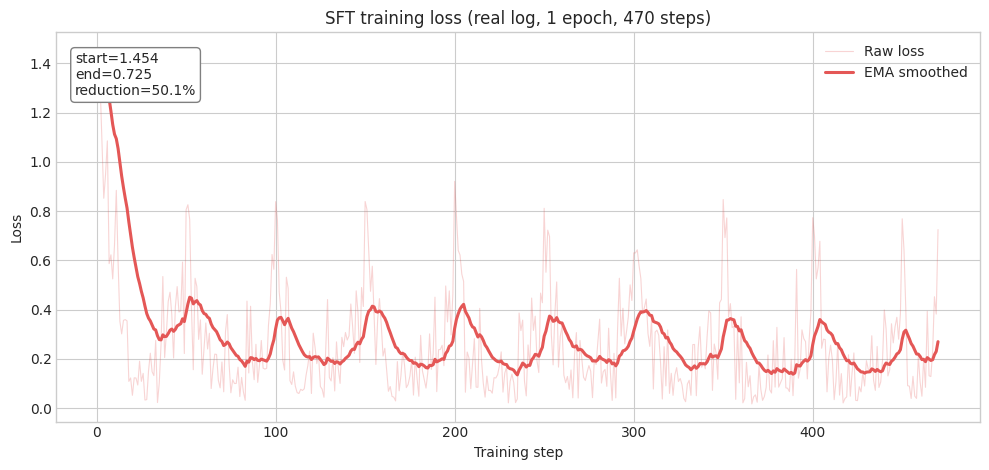

,steps,epoch_end,loss_start,loss_end
0,470,1.0,1.4539,0.725


In [3]:
import re, ast
from pathlib import Path

log_text = Path('/home/ray/sft/logs/run_exp2.log').read_text(errors='ignore')
sft_entries = []
for m in re.finditer(r"\{'loss': .*?\}", log_text):
    try:
        d = ast.literal_eval(m.group(0))
    except Exception:
        continue
    if 'loss' in d and 'epoch' in d:
        sft_entries.append({'loss': float(d['loss']), 'epoch': float(d['epoch'])})

segments = []
cur = [sft_entries[0]]
for prev, e in zip(sft_entries, sft_entries[1:]):
    if e['epoch'] + 1e-9 < prev['epoch']:
        segments.append(cur)
        cur = [e]
    else:
        cur.append(e)
segments.append(cur)

sft_segment = max(segments, key=len)
sft_steps = np.arange(1, len(sft_segment) + 1)
sft_loss = np.array([x['loss'] for x in sft_segment])
sft_epoch = np.array([x['epoch'] for x in sft_segment])

# Exponential moving average for a cleaner presentation while preserving the raw curve
alpha = 0.08
sft_smooth = np.empty_like(sft_loss)
sft_smooth[0] = sft_loss[0]
for i in range(1, len(sft_loss)):
    sft_smooth[i] = alpha * sft_loss[i] + (1 - alpha) * sft_smooth[i - 1]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(sft_steps, sft_loss, color=COLORS['post_sft'], linewidth=0.8, alpha=0.25, label='Raw loss')
ax.plot(sft_steps, sft_smooth, color=COLORS['post_sft'], linewidth=2.2, label='EMA smoothed')
ax.set_title('SFT training loss (real log, 1 epoch, 470 steps)')
ax.set_xlabel('Training step')
ax.set_ylabel('Loss')
ax.legend()
summary_text = f"start={sft_loss[0]:.3f}\nend={sft_loss[-1]:.3f}\nreduction={(1 - sft_loss[-1]/sft_loss[0])*100:.1f}%"
ax.text(0.02, 0.95, summary_text, transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', fc='white', ec='gray'))
plt.tight_layout()
plt.show()

pd.DataFrame({
    'steps': [len(sft_segment)],
    'epoch_end': [sft_epoch[-1]],
    'loss_start': [sft_loss[0]],
    'loss_end': [sft_loss[-1]],
})


## 3. Quality (BFCL v4)

We evaluated on the full BFCL v4 benchmark (13 categories, 3641 samples) for baseline → SFT → GRPO. Quantized models (FP8, W4A16) were spot-checked on the assignment-critical `simple_python` subset (400 samples).

**Main finding**: SFT drives the biggest quality gain (+5.7pp weighted core accuracy). GRPO further improves structured categories like `parallel_multiple` (+7.5pp) at the cost of slight regression on `irrelevance` (−1.3pp).


### Quality preservation under quantization

FP8 and W4A16 both preserve accuracy on `simple_python` — in fact scoring slightly higher (96.50%) than the full-rerun BF16 (96.25%), within 1-sample binomial noise (Wilson 95% CI overlaps).

EAGLE-3 is **lossless by construction**: every accepted token is verified by the target model. No separate quality evaluation needed.


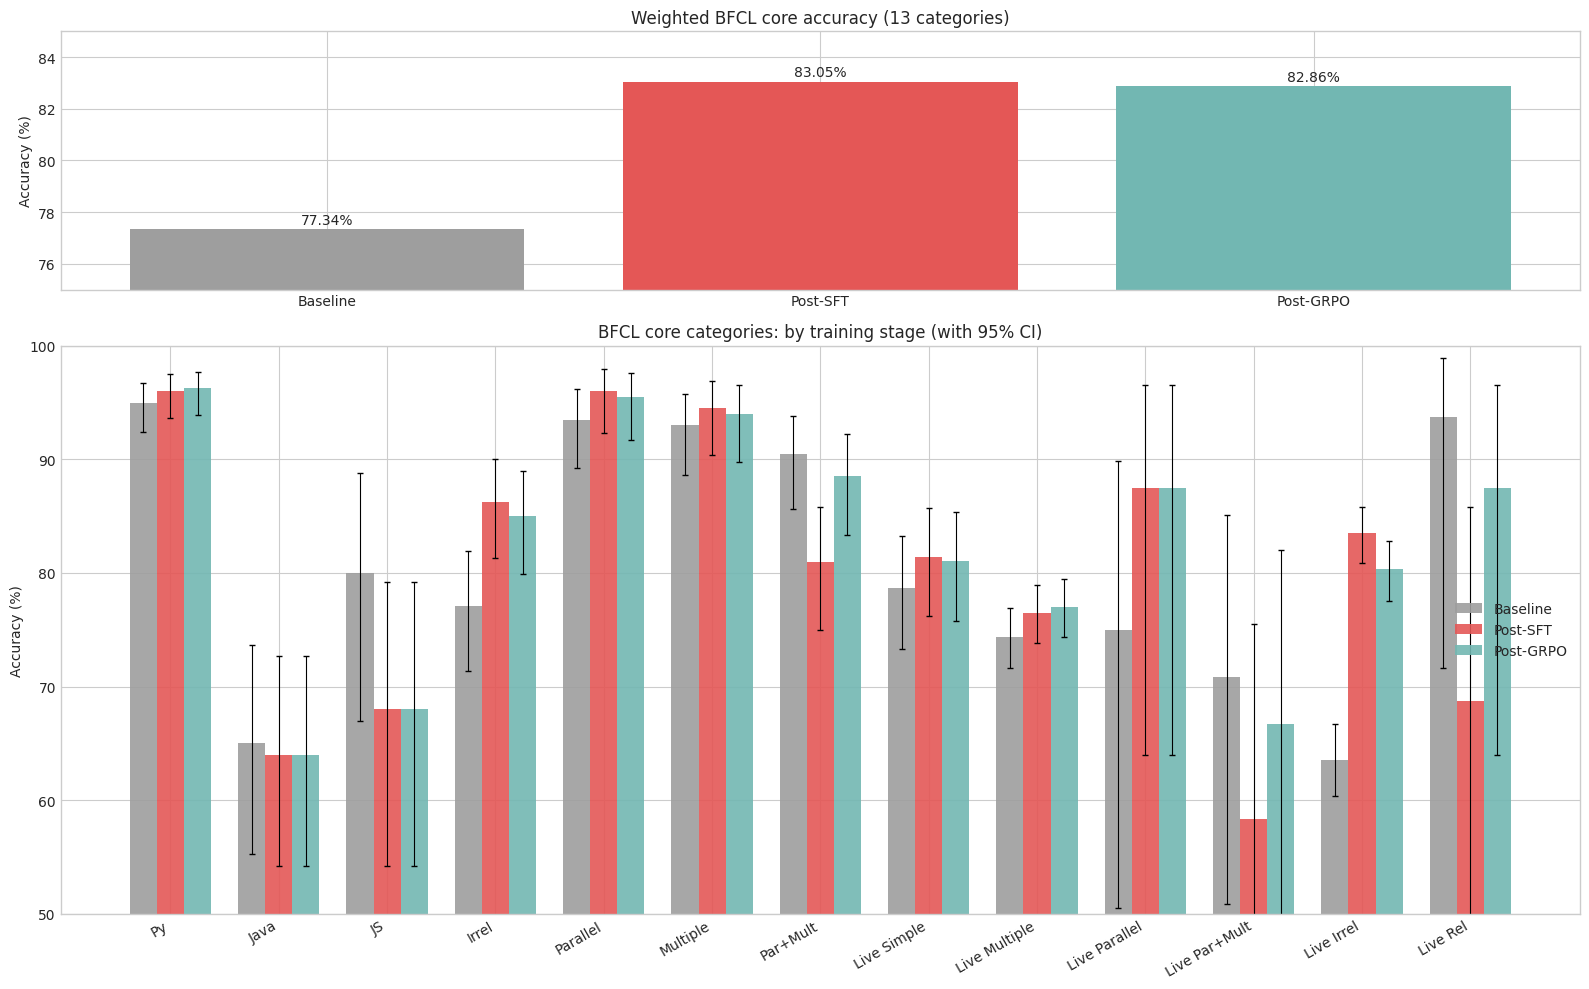

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[1, 2.2])

axes[0].bar(core_summary_df['config'], core_summary_df['weighted_core_accuracy'], color=['#9E9E9E', '#E45756', '#72B7B2'])
axes[0].set_title('Weighted BFCL core accuracy (13 categories)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(75, 85)
for i, row in core_summary_df.iterrows():
    axes[0].text(i, row['weighted_core_accuracy'] + 0.2, f"{row['weighted_core_accuracy']:.2f}%", ha='center')

x = np.arange(len(core_categories))
width = 0.25
cfgs = [
    ('baseline', 'Baseline', '#9E9E9E'),
    ('post_sft', 'Post-SFT', '#E45756'),
    ('post_grpo', 'Post-GRPO', '#72B7B2'),
]
for idx, (cfg, label, color) in enumerate(cfgs):
    vals = [bfcl_full[cfg][cat]['accuracy'] for cat in core_categories]
    ns = [bfcl_full[cfg][cat]['n'] for cat in core_categories]
    ks = [round(v / 100 * n) for v, n in zip(vals, ns)]
    cis = [wilson_ci(k, n) for k, n in zip(ks, ns)]
    err_low = [v - lo * 100 for v, (lo, hi) in zip(vals, cis)]
    err_high = [hi * 100 - v for v, (lo, hi) in zip(vals, cis)]
    xpos = x + (idx - 1) * width
    axes[1].bar(xpos, vals, width=width, label=label, color=color, alpha=0.9)
    axes[1].errorbar(xpos, vals, yerr=[err_low, err_high], fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

axes[1].set_xticks(x, core_labels, rotation=30, ha='right')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('BFCL core categories: by training stage (with 95% CI)')
axes[1].legend()
axes[1].set_ylim(50, 100)

plt.tight_layout()
plt.show()


In [5]:

full_core_table = pd.DataFrame({
    'category': core_categories,
    'Baseline': [bfcl_full['baseline'][c]['accuracy'] for c in core_categories],
    'Post-SFT': [bfcl_full['post_sft'][c]['accuracy'] for c in core_categories],
    'Post-GRPO': [bfcl_full['post_grpo'][c]['accuracy'] for c in core_categories],
})
full_core_table


,category,Baseline,Post-SFT,Post-GRPO
0,simple_python,95.00,96.00,96.25
1,simple_java,65.00,64.00,64.00
2,simple_javascript,80.00,68.00,68.00
3,irrelevance,77.08,86.25,85.00
4,parallel,93.50,96.00,95.50
5,multiple,93.00,94.50,94.00
6,parallel_multiple,90.50,81.00,88.50
7,live_simple,78.68,81.40,81.01
8,live_multiple,74.36,76.45,77.02
9,live_parallel,75.00,87.50,87.50


In [6]:
base = bfcl_df.loc[bfcl_df['config'] == 'Baseline', 'accuracy'].iloc[0]
delta_df = bfcl_df[['config', 'accuracy']].copy()
delta_df['delta_vs_baseline_pp'] = delta_df['accuracy'] - base
delta_df


,config,accuracy,delta_vs_baseline_pp
0,Baseline,95.00,0.00
1,Post-SFT,96.00,1.00
2,Post-GRPO,96.25,1.25
3,FP8,96.50,1.50
4,W4A16,96.50,1.50


## 4. Latency and Throughput

All latency measured with [`vllm bench serve`](https://docs.vllm.ai/en/latest/cli/bench/serve.html) on **real ToolACE prompts** from the held-out split. 100 requests per concurrency level, 5 warmup rounds, tools included in every request.

The client expects **16-32 concurrent requests** in production. We benchmark at c=1 (single-user latency), c=16 and c=32 (production load).

| Dataset | Prompts | Use case |
|---------|:-------:|----------|
| `bench_toolace.jsonl` | 100 (from ToolACE held-out split) | Real tool-calling requests |


### Engine selection: vLLM vs SGLang

We benchmarked both vLLM and SGLang on BF16. **vLLM won on all metrics** — lower latency, higher throughput, and native EAGLE-3 support. SGLang's EAGLE path required manual checkpoint patching and still underperformed.


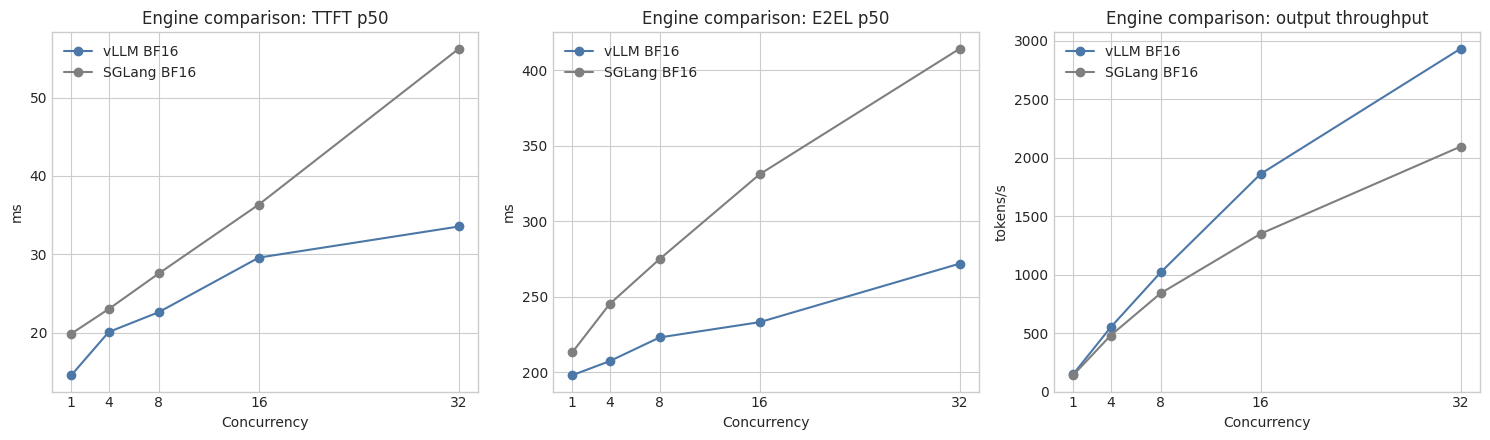

ttft_p50_ms            e2el_p50_ms               output_tps  \
engine      SGLang BF16  vLLM BF16 SGLang BF16   vLLM BF16  SGLang BF16   
concurrency                                                               
1             19.896155  14.595886  212.931694  197.845653   139.146960   
4             23.043571  20.115225  245.047528  207.189888   478.767148   
8             27.574019  22.643084  274.835163  222.903988   840.025183   
16            36.360281  29.592795  330.995870  233.026775  1349.485214   
32            56.226952  33.557803  414.182721  271.796087  2095.635011   

                          
engine         vLLM BF16  
concurrency               
1             146.702575  
4             548.093255  
8            1018.503310  
16           1861.146865  
32           2933.445582

In [7]:

engine_rows = []
for engine_name, label in [('vLLM_BF16', 'vLLM BF16'), ('SGLang_BF16', 'SGLang BF16')]:
    for c in [1, 4, 8, 16, 32]:
        s = engine_compare[engine_name][str(c)]
        engine_rows.append({
            'engine': label,
            'concurrency': c,
            'ttft_p50_ms': s['ttft_p50_ms'],
            'e2el_p50_ms': s['e2el_p50_ms'],
                        'output_tps': s['output_tps'],
        })
engine_df = pd.DataFrame(engine_rows)
engine_df

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for label, color in [('vLLM BF16', '#4C78A8'), ('SGLang BF16', '#7F7F7F')]:
    sub = engine_df[engine_df['engine'] == label].sort_values('concurrency')
    axes[0].plot(sub['concurrency'], sub['ttft_p50_ms'], marker='o', label=label, color=color)
    axes[1].plot(sub['concurrency'], sub['e2el_p50_ms'], marker='o', label=label, color=color)
    axes[2].plot(sub['concurrency'], sub['output_tps'], marker='o', label=label, color=color)

axes[0].set_title('Engine comparison: TTFT p50')
axes[0].set_ylabel('ms')
axes[1].set_title('Engine comparison: E2EL p50')
axes[1].set_ylabel('ms')
axes[2].set_title('Engine comparison: output throughput')
axes[2].set_ylabel('tokens/s')
for ax in axes:
    ax.set_xlabel('Concurrency')
    ax.set_xticks([1, 4, 8, 16, 32])
    ax.legend()
plt.tight_layout()
plt.show()

engine_pivot = engine_df.pivot(index='concurrency', columns='engine', values=['ttft_p50_ms', 'e2el_p50_ms', 'output_tps'])
engine_pivot


### Latency by quantization config

Four lines per subplot: BF16, FP8 dynamic, W4A16, EAGLE3 fine-tuned. Solid = p50 (median), dashed = p95, shaded = IQR (p25-p75). Values annotated at c=32.


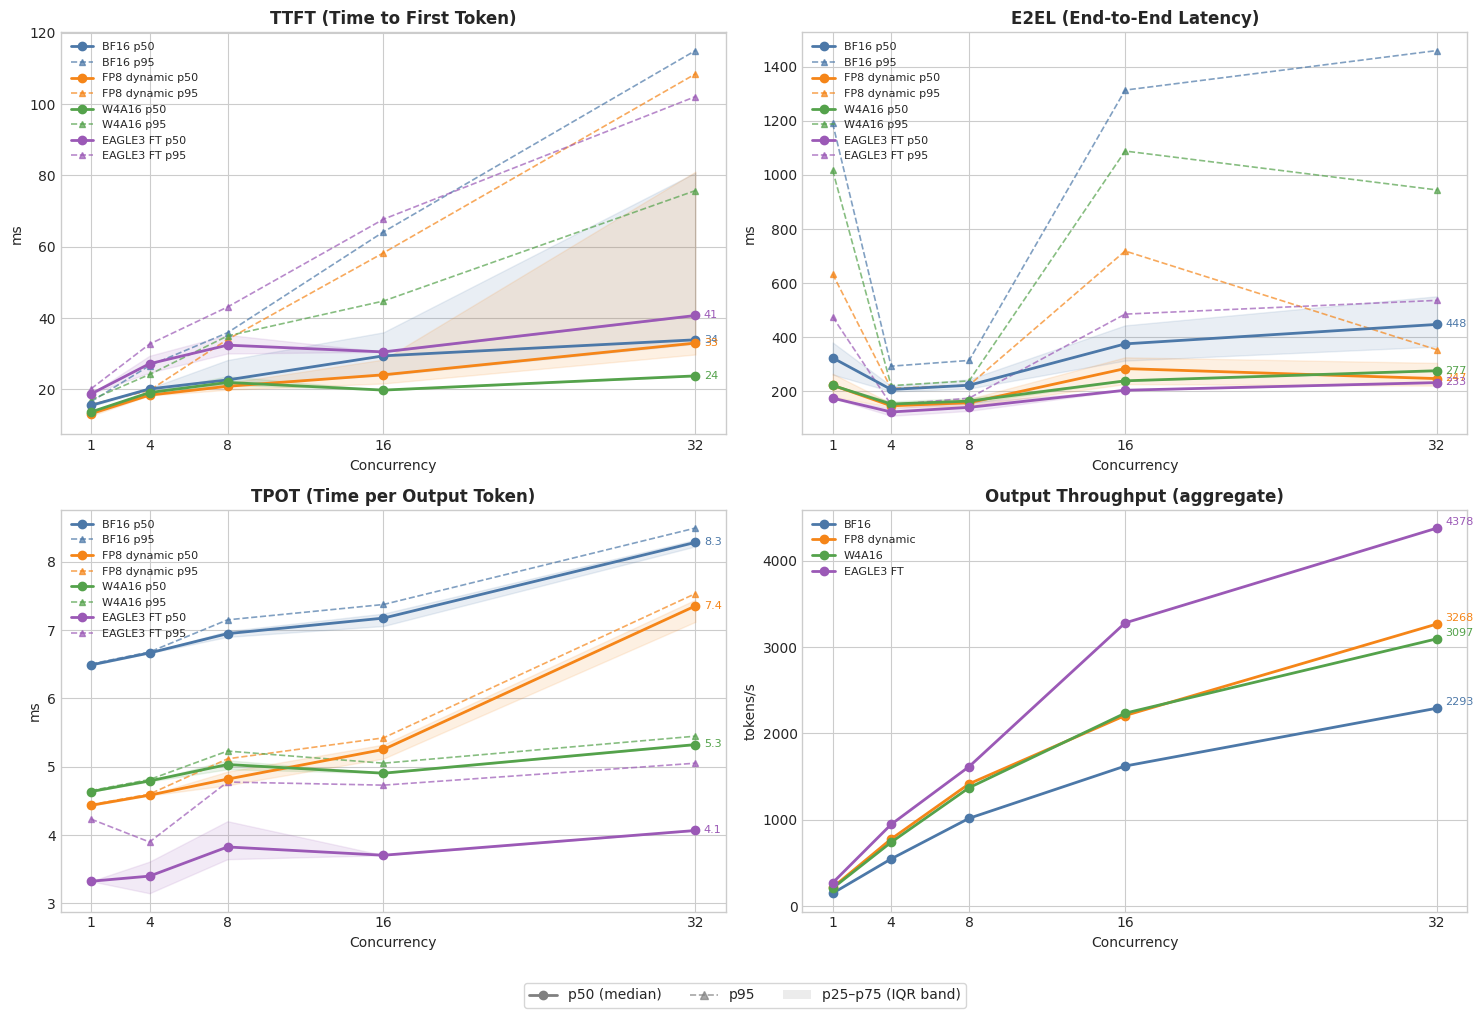

In [8]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

concurrency = np.array([1, 4, 8, 16, 32])
cfg_labels = {'BF16': 'BF16', 'FP8_dynamic': 'FP8 dynamic', 'W4A16': 'W4A16', 'EAGLE3_FT': 'EAGLE3 FT'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for cfg in ['BF16', 'FP8_dynamic', 'W4A16', 'EAGLE3_FT']:
    sub = lat_df[lat_df['config'] == cfg].sort_values('concurrency')
    color = COLORS[cfg]
    lbl = cfg_labels[cfg]

    # ── TTFT (top-left) ──
    ax = axes[0, 0]
    ax.fill_between(sub['concurrency'], sub['ttft_p25'], sub['ttft_p75'],
                     alpha=0.12, color=color)
    ax.plot(sub['concurrency'], sub['ttft_p50'], marker='o', color=color,
            linewidth=2, label=f'{lbl} p50', zorder=5)
    ax.plot(sub['concurrency'], sub['ttft_p95'], marker='^', markersize=5,
            linestyle='--', linewidth=1.2, color=color, alpha=0.7,
            label=f'{lbl} p95')
    # annotate last point
    ax.annotate(f'{sub["ttft_p50"].iloc[-1]:.0f}',
                xy=(32, sub['ttft_p50'].iloc[-1]),
                textcoords='offset points', xytext=(6, -2), fontsize=8, color=color)

    # ── E2EL (top-right) ──
    ax = axes[0, 1]
    ax.fill_between(sub['concurrency'], sub['e2el_p25'], sub['e2el_p75'],
                     alpha=0.12, color=color)
    ax.plot(sub['concurrency'], sub['e2el_p50'], marker='o', color=color,
            linewidth=2, label=f'{lbl} p50', zorder=5)
    ax.plot(sub['concurrency'], sub['e2el_p95'], marker='^', markersize=5,
            linestyle='--', linewidth=1.2, color=color, alpha=0.7,
            label=f'{lbl} p95')
    ax.annotate(f'{sub["e2el_p50"].iloc[-1]:.0f}',
                xy=(32, sub['e2el_p50'].iloc[-1]),
                textcoords='offset points', xytext=(6, -2), fontsize=8, color=color)

    # ── TPOT (bottom-left) ──
    ax = axes[1, 0]
    ax.fill_between(sub['concurrency'],
                     [bench[cfg][str(c)]['tpot'].get('p25', bench[cfg][str(c)]['tpot'].get('p50', 0)) for c in concurrency],
                     [bench[cfg][str(c)]['tpot'].get('p75', bench[cfg][str(c)]['tpot'].get('p50', 0)) for c in concurrency],
                     alpha=0.12, color=color)
    ax.plot(sub['concurrency'], sub['tpot_p50'], marker='o', color=color,
            linewidth=2, label=f'{lbl} p50', zorder=5)
    tpot_p95 = [bench[cfg][str(c)]['tpot'].get('p95', bench[cfg][str(c)]['tpot'].get('p50', 0)) for c in concurrency]
    ax.plot(concurrency, tpot_p95, marker='^', markersize=5,
            linestyle='--', linewidth=1.2, color=color, alpha=0.7,
            label=f'{lbl} p95')
    ax.annotate(f'{sub["tpot_p50"].iloc[-1]:.1f}',
                xy=(32, sub['tpot_p50'].iloc[-1]),
                textcoords='offset points', xytext=(6, -2), fontsize=8, color=color)

    # ── Output throughput (bottom-right) ──
    ax = axes[1, 1]
    ax.plot(sub['concurrency'], sub['output_tps'], marker='o', color=color,
            linewidth=2, label=lbl, zorder=5)
    ax.annotate(f'{sub["output_tps"].iloc[-1]:.0f}',
                xy=(32, sub['output_tps'].iloc[-1]),
                textcoords='offset points', xytext=(6, 2), fontsize=8, color=color)

# ── Titles, labels, legend key ──
titles = [
    'TTFT (Time to First Token)',
    'E2EL (End-to-End Latency)',
    'TPOT (Time per Output Token)',
    'Output Throughput (aggregate)',
]
ylabels = ['ms', 'ms', 'ms', 'tokens/s']

for ax, title, ylabel in zip(axes.ravel(), titles, ylabels):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel(ylabel)
    ax.set_xticks(concurrency)
    ax.set_xticklabels(concurrency)

# Shared legend with explicit line style explanation
legend_elements = [
    mlines.Line2D([], [], color='gray', marker='o', linewidth=2, label='p50 (median)'),
    mlines.Line2D([], [], color='gray', marker='^', linewidth=1.2, linestyle='--', alpha=0.7, label='p95'),
    mpatches.Patch(facecolor='gray', alpha=0.15, label='p25–p75 (IQR band)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

# Per-config legend in each subplot
for ax in axes.ravel():
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


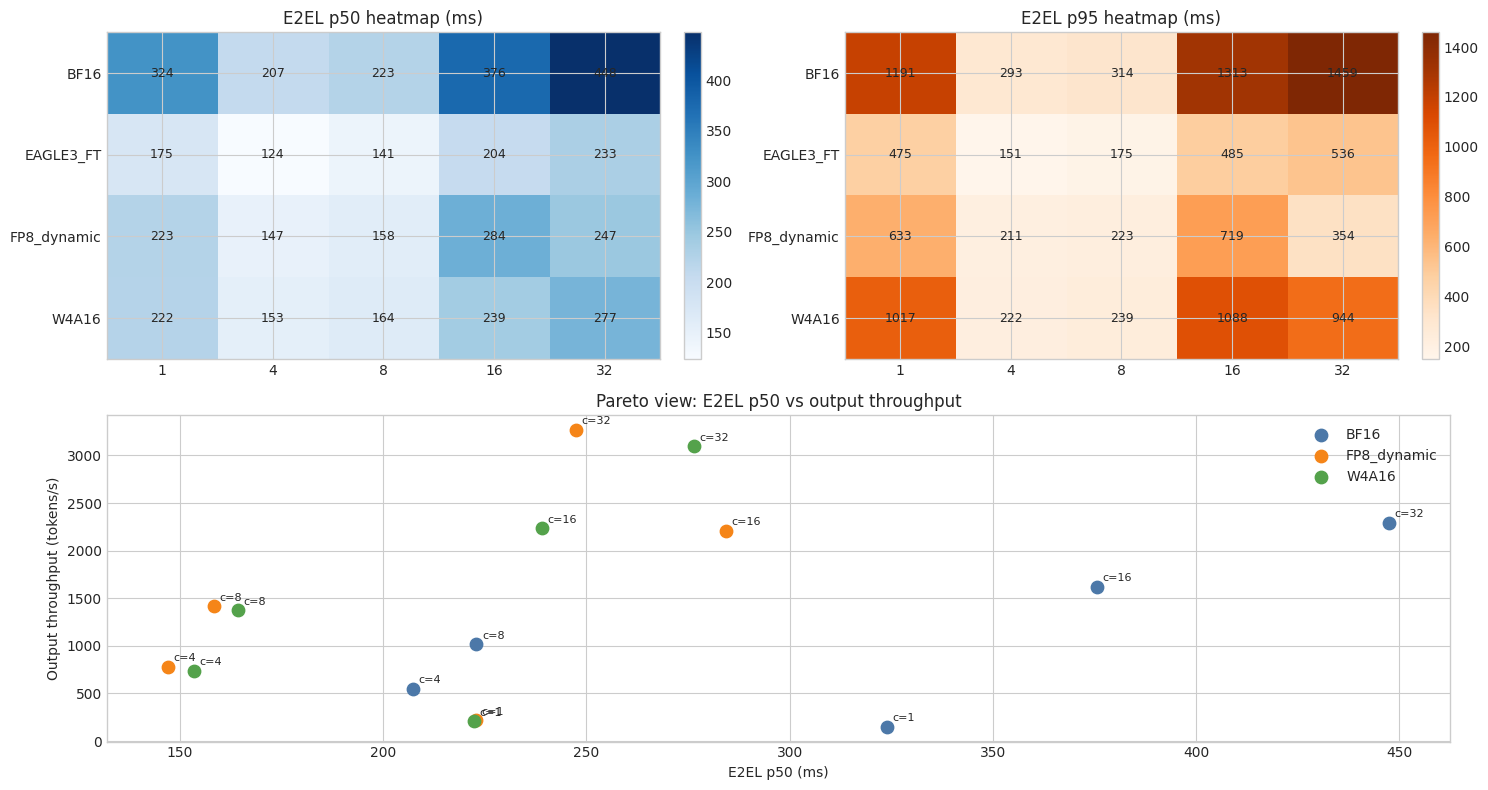

In [9]:
p50 = lat_df.pivot(index='config', columns='concurrency', values='e2el_p50')
p95 = lat_df.pivot(index='config', columns='concurrency', values='e2el_p95')
throughput = lat_df.pivot(index='config', columns='concurrency', values='output_tps')

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

im1 = ax1.imshow(p50.values, aspect='auto', cmap='Blues')
ax1.set_title('E2EL p50 heatmap (ms)')
ax1.set_xticks(range(len(p50.columns)), p50.columns)
ax1.set_yticks(range(len(p50.index)), p50.index)
for i in range(p50.shape[0]):
    for j in range(p50.shape[1]):
        ax1.text(j, i, f'{p50.values[i,j]:.0f}', ha='center', va='center', fontsize=9)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.imshow(p95.values, aspect='auto', cmap='Oranges')
ax2.set_title('E2EL p95 heatmap (ms)')
ax2.set_xticks(range(len(p95.columns)), p95.columns)
ax2.set_yticks(range(len(p95.index)), p95.index)
for i in range(p95.shape[0]):
    for j in range(p95.shape[1]):
        ax2.text(j, i, f'{p95.values[i,j]:.0f}', ha='center', va='center', fontsize=9)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

for cfg in ['BF16', 'FP8_dynamic', 'W4A16']:
    sub = lat_df[lat_df['config'] == cfg].sort_values('concurrency')
    ax3.scatter(sub['e2el_p50'], sub['output_tps'], s=80, color=COLORS[cfg], label=cfg)
    for _, row in sub.iterrows():
        ax3.annotate(f"c={int(row['concurrency'])}", (row['e2el_p50'], row['output_tps']), textcoords='offset points', xytext=(4,4), fontsize=8)
ax3.set_title('Pareto view: E2EL p50 vs output throughput')
ax3.set_xlabel('E2EL p50 (ms)')
ax3.set_ylabel('Output throughput (tokens/s)')
ax3.legend()

plt.tight_layout()
plt.show()


In [10]:
speedup_df = pd.DataFrame([
    {
        'config': 'FP8_dynamic',
        'ttft_speedup_vs_bf16': bf16_c1['ttft']['p50'] / fp8_c1['ttft']['p50'],
        'e2el_speedup_vs_bf16': bf16_c1['lat']['p50'] / fp8_c1['lat']['p50'],
        'throughput_gain_vs_bf16': fp8_c1['output_throughput'] / bf16_c1['output_throughput'],
    },
    {
        'config': 'W4A16',
        'ttft_speedup_vs_bf16': bf16_c1['ttft']['p50'] / w4_c1['ttft']['p50'],
        'e2el_speedup_vs_bf16': bf16_c1['lat']['p50'] / w4_c1['lat']['p50'],
        'throughput_gain_vs_bf16': w4_c1['output_throughput'] / bf16_c1['output_throughput'],
    },
]).round(3)
speedup_df


,config,ttft_speedup_vs_bf16,e2el_speedup_vs_bf16,throughput_gain_vs_bf16
0,FP8_dynamic,1.178,1.453,1.448
1,W4A16,1.135,1.457,1.389


## 5. EAGLE-3 Speculative Decoding

EAGLE-3 uses a small draft model to propose multiple tokens per step, verified by the target model in a single forward pass. It is **lossless**: output is identical to standard decoding.

### What worked and what didn't

Our first attempt trained the draft from scratch on ToolACE — it failed because the draft only learned JSON token patterns and had poor acceptance rate on natural language (val accuracy: 0.62/0.39/0.24 for tokens 0/1/2).

**The fix**: fine-tune the official `RedHatAI/Qwen3-8B-speculator.eagle3` (already trained on general text) on ToolACE for just 1 epoch. This preserves general capability while adapting to our domain (val accuracy: **0.82/0.64/0.49**).

| Attempt | Val accuracy (tok 0/1/2) | E2EL speedup | Outcome |
|---------|:---:|:---:|:---:|
| Train from scratch on ToolACE | 0.62 / 0.39 / 0.24 | 0.77x (slower) | Failed |
| **Fine-tune official on ToolACE** | **0.82 / 0.64 / 0.49** | **1.85x** | **Success** |


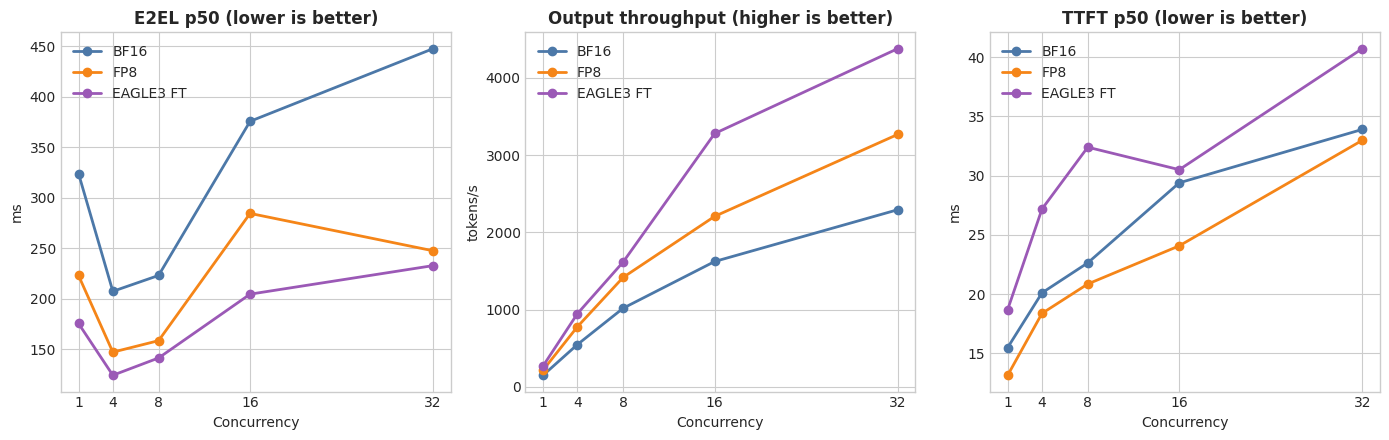

,config,E2EL p50 (ms),TPOT p50 (ms),Output tok/s,TTFT p50 (ms)
0,BF16 (no spec),323.9,6.5,150.4,15.5
1,FP8 dynamic,222.9,4.4,217.7,13.2
2,EAGLE3 FT (BF16),175.4,3.3,271.3,18.7


In [11]:
if 'EAGLE3_FT' in bench:
    eagle_comparison = pd.DataFrame([
        {
            'config': 'BF16 (no spec)',
            'E2EL p50 (ms)': bench['BF16']['1']['lat']['p50'],
            'TPOT p50 (ms)': bench['BF16']['1']['tpot']['p50'],
            'Output tok/s': bench['BF16']['1']['output_throughput'],
            'TTFT p50 (ms)': bench['BF16']['1']['ttft']['p50'],
        },
        {
            'config': 'FP8 dynamic',
            'E2EL p50 (ms)': bench['FP8_dynamic']['1']['lat']['p50'],
            'TPOT p50 (ms)': bench['FP8_dynamic']['1']['tpot']['p50'],
            'Output tok/s': bench['FP8_dynamic']['1']['output_throughput'],
            'TTFT p50 (ms)': bench['FP8_dynamic']['1']['ttft']['p50'],
        },
        {
            'config': 'EAGLE3 FT (BF16)',
            'E2EL p50 (ms)': bench['EAGLE3_FT']['1']['lat']['p50'],
            'TPOT p50 (ms)': bench['EAGLE3_FT']['1']['tpot']['p50'],
            'Output tok/s': bench['EAGLE3_FT']['1']['output_throughput'],
            'TTFT p50 (ms)': bench['EAGLE3_FT']['1']['ttft']['p50'],
        },
    ]).round(1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    concurrency = [1, 4, 8, 16, 32]
    for cfg, color, label in [
        ('BF16', COLORS['BF16'], 'BF16'),
        ('FP8_dynamic', COLORS['FP8_dynamic'], 'FP8'),
        ('EAGLE3_FT', COLORS['EAGLE3_FT'], 'EAGLE3 FT'),
    ]:
        e2el = [bench[cfg][str(c)]['lat']['p50'] for c in concurrency]
        tps = [bench[cfg][str(c)]['output_throughput'] for c in concurrency]
        ttft = [bench[cfg][str(c)]['ttft']['p50'] for c in concurrency]
        axes[0].plot(concurrency, e2el, marker='o', color=color, label=label, linewidth=2)
        axes[1].plot(concurrency, tps, marker='o', color=color, label=label, linewidth=2)
        axes[2].plot(concurrency, ttft, marker='o', color=color, label=label, linewidth=2)

    axes[0].set_title('E2EL p50 (lower is better)', fontweight='bold')
    axes[0].set_ylabel('ms')
    axes[1].set_title('Output throughput (higher is better)', fontweight='bold')
    axes[1].set_ylabel('tokens/s')
    axes[2].set_title('TTFT p50 (lower is better)', fontweight='bold')
    axes[2].set_ylabel('ms')
    for ax in axes:
        ax.set_xlabel('Concurrency')
        ax.set_xticks(concurrency)
        ax.legend()
    plt.tight_layout()
    plt.show()

    display(eagle_comparison)
else:
    print('EAGLE3_FT not in benchmark data')


### Deployment

```bash
# Recommended: EAGLE3 + production optimizations
bash scripts/serve_eagle.sh

# With FP8 quantization
bash scripts/serve_eagle.sh --quantization fp8
```

Draft weights: [kenkaneki/Qwen3-8B-ToolACE-speculator.eagle3](https://huggingface.co/kenkaneki/Qwen3-8B-ToolACE-speculator.eagle3)


## 6. Production Recommendation

| Scenario | Config | Why |
|----------|--------|-----|
| **Maximum speed** | EAGLE3 FT | 1.85x E2EL speedup, lossless, 4378 tok/s at c=32 |
| **Simple deployment** | FP8 dynamic | No draft model needed, 1.5x throughput, zero quality loss |
| **Minimum footprint** | W4A16 | 5.7 GB model size (vs 16 GB BF16), good latency |
| **Baseline** | BF16 | No optimization, simplest to debug |

All configs served via vLLM with prefix caching, chunked prefill, and hermes tool-call parser.


## 7. Error Analysis

Where does the model still fail? We analyzed BFCL score files for the post-GRPO model to categorize errors.


In [12]:
err_rows = []
for cat, info in error_analysis.items():
    if info['failures'] > 0:
        top_errors = list(info['error_types'].items())[:2]
        top_str = '; '.join(f'{t[:50]}({c})' for t, c in top_errors)
        err_rows.append({
            'category': cat,
            'total': info['total'],
            'failures': info['failures'],
            'fail_rate': f"{100*info['failures']/info['total']:.1f}%",
            'top_errors': top_str,
        })
err_df = pd.DataFrame(err_rows).sort_values('failures', ascending=False)
err_df


,category,total,failures,fail_rate,top_errors
8,live_multiple,242,242,100.0%,Invalid syntax. Failed to decode AST. invalid ...
11,live_irrelevance,174,174,100.0%,Valid syntax. Successfully decode AST when it ...
7,live_simple,49,49,100.0%,Invalid syntax. Failed to decode AST. invalid ...
3,irrelevance,36,36,100.0%,Valid syntax. Successfully decode AST when it ...
1,simple_java,36,36,100.0%,Invalid syntax. Failed to decode AST. Error pa...
6,parallel_multiple,23,23,100.0%,Wrong number of functions.(18); unknown(18)
2,simple_javascript,16,16,100.0%,Invalid value for parameter 'coordinates': [30...
0,simple_python,15,15,100.0%,Invalid value for parameter 'operating_hours':...
5,multiple,12,12,100.0%,Wrong number of functions.(2); Function name '...
4,parallel,9,9,100.0%,unknown(9); Wrong number of functions.(4)


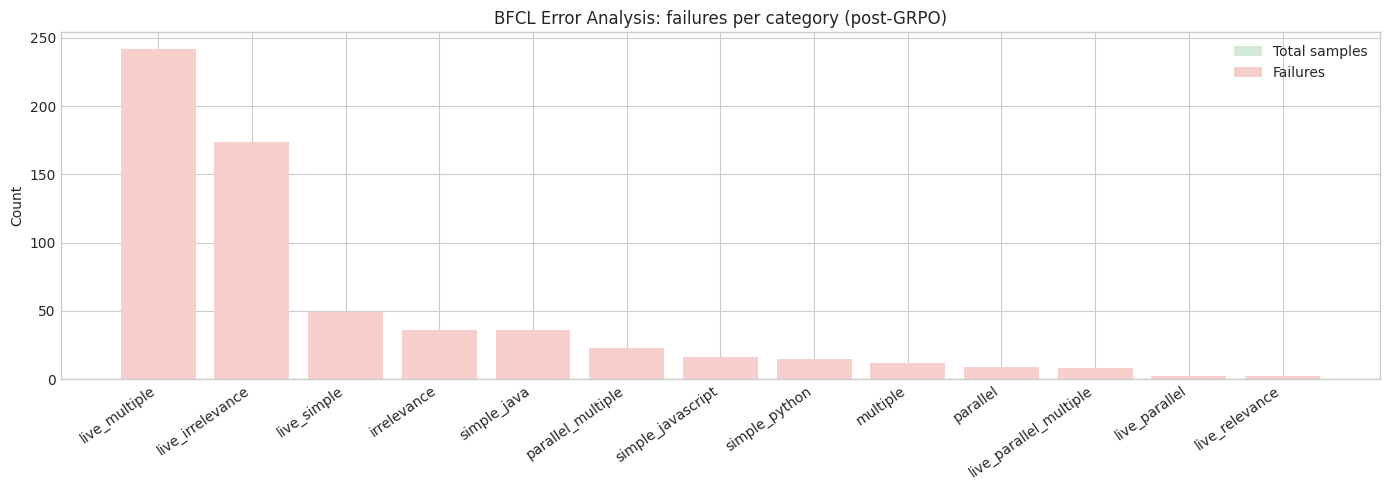

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
cats = [r['category'] for _, r in err_df.iterrows()]
fails = [r['failures'] for _, r in err_df.iterrows()]
totals = [r['total'] for _, r in err_df.iterrows()]
x = np.arange(len(cats))
ax.bar(x, totals, color='#D5E8D4', label='Total samples')
ax.bar(x, fails, color='#F8CECC', label='Failures')
ax.set_xticks(x, cats, rotation=35, ha='right')
ax.set_ylabel('Count')
ax.set_title('BFCL Error Analysis: failures per category (post-GRPO)')
ax.legend()
plt.tight_layout()
plt.show()


### Failure patterns

The two dominant failure modes:

1. **False positives on irrelevance** (210 failures): The model generates valid-looking tool calls when it should refuse. This is the single largest error category and affects both `irrelevance` and `live_irrelevance`. A potential fix: add irrelevance-detection reward to GRPO.

2. **Structural errors** (parallel/multiple): Wrong number of function calls — the model under-generates or over-generates when multiple parallel calls are expected. GRPO improved `parallel_multiple` significantly (+7.5pp) but there's still room.

3. **Language-specific AST failures** (Java/JS): The model occasionally produces Python-style syntax in Java/JavaScript contexts. Not critical for the client's Python-only use case.


## 8. Reproducibility

All code, configs, and result files are in [github.com/aimedvedevq/toolaceqwen](https://github.com/aimedvedevq/toolaceqwen).

Models on HuggingFace:
- [kenkaneki/Qwen3-8B-ToolACE](https://huggingface.co/kenkaneki/Qwen3-8B-ToolACE) — post-GRPO merged (BF16)
- [kenkaneki/Qwen3-8B-ToolACE-W4A16](https://huggingface.co/kenkaneki/Qwen3-8B-ToolACE-W4A16) — W4A16 quantized
- [kenkaneki/Qwen3-8B-ToolACE-speculator.eagle3](https://huggingface.co/kenkaneki/Qwen3-8B-ToolACE-speculator.eagle3) — EAGLE-3 draft head

```bash
# Full pipeline from scratch
make train && make quantize && make eval && make bench && make report
```

| Artifact | Source |
|----------|--------|
| BFCL accuracy | `results/bfcl_full_core.json` |
| Latency benchmarks | `results/bench_inference.json` |
| GRPO training curves | `results/grpo_rewards.json` |
| Error analysis | `results/error_analysis.json` |
| Raw bench outputs | `results/bench/*.json` |

Hardware: NVIDIA H100 80GB HBM3. Total training time: ~62 min.
